In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm import tqdm

save_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph_manual")
metadata_dir = save_dir / "metadata"

gauges = gpd.read_parquet(metadata_dir / "gauges.parquet").set_index('site_id')

subs_df = pd.read_parquet(metadata_dir / 'subbasins.parquet', columns=['site_id', 'is_gauge', 'uparea_km2', 'outlet_id'])
subs_df.index = subs_df.index.astype(str)

basin_subbasin_dict = subs_df.groupby('outlet_id').apply(lambda g: g.index.tolist(), include_groups=False).to_dict()

In [2]:
from data import ZarrBasinStore
store_path = Path("/scratch4/workspace/tlanghorst_umass_edu-zbs_vD")
store = ZarrBasinStore(store_path)

In [3]:
subs_df['original_comid'] = subs_df.index

# A small % of gauges are dropped if they don't match well.
common_idx = subs_df.index.intersection(gauges.index)
subs_df.loc[common_idx, 'original_comid'] = gauges.loc[common_idx, 'COMID'].astype(str)
subs_df

,is_gauge,uparea_km2,outlet_id,original_comid
site_id,,,,
23021321,False,209.123678,EAUF-A3750050,23021321
23021261,False,213.109547,EAUF-A3750050,23021261
23021244,False,291.030672,EAUF-A3750050,23021244
23021122,False,477.964586,EAUF-A3750050,23021122
23021112,False,394.295017,EAUF-A3750050,23021112
...,...,...,...,...
81003765,False,1613.152478,USGS-15908000,81003765
81001414,False,1473.949940,USGS-15908000,81001414
81001413,False,2751.705206,USGS-15908000,81001413


In [4]:
paths = Path("/nas/cee-ice/data/MERIT-BASINS/v07_to_bugfix").glob("v07_to_bugfix_pfaf1_*.csv")
bugfix_to_v07 = pd.concat([pd.read_csv(p, dtype=str) for p in paths]).set_index('COMID_bugfix')
subs_df = subs_df.merge(bugfix_to_v07, how='left', left_on='original_comid', right_index=True)
subs_df

,is_gauge,uparea_km2,outlet_id,original_comid,COMID_v07
site_id,,,,,
23021321,False,209.123678,EAUF-A3750050,23021321,23020861
23021261,False,213.109547,EAUF-A3750050,23021261,23020837
23021244,False,291.030672,EAUF-A3750050,23021244,23020833
23021122,False,477.964586,EAUF-A3750050,23021122,23020781
23021112,False,394.295017,EAUF-A3750050,23021112,23020778
...,...,...,...,...,...
81003765,False,1613.152478,USGS-15908000,81003765,81003353
81001414,False,1473.949940,USGS-15908000,81001414,81002712
81001413,False,2751.705206,USGS-15908000,81001413,81002593


In [5]:
MHS_dir = Path("/nas/cee-water/cjgleason/heejin/HYDRO_combination/02Result/Unified_Hydrography/")

mhs = pd.concat([pd.read_csv(f)[['COMID','reach_id']].drop_duplicates().dropna() for f in MHS_dir.glob("all_*_MHS.csv")])
mhs

,COMID,reach_id
320,13037099,1.327510e+10
323,13037099,1.327510e+10
326,13037099,1.327510e+10
355,13066945,1.322620e+10
386,13106853,1.312200e+10
...,...,...
2327271,91007672,9.141000e+10
2327278,91007672,9.141000e+10
2327306,91007671,9.141000e+10
2327307,91007671,9.141000e+10


In [6]:
subs_df.dropna(subset='COMID_v07', inplace=True)
subs_df['COMID_v07'] = subs_df['COMID_v07'].astype(int)

In [62]:
subs_df

,is_gauge,uparea_km2,outlet_id,original_comid,COMID_v07
site_id,,,,,
23021321,False,209.123678,EAUF-A3750050,23021321,23020861
23021261,False,213.109547,EAUF-A3750050,23021261,23020837
23021244,False,291.030672,EAUF-A3750050,23021244,23020833
23021122,False,477.964586,EAUF-A3750050,23021122,23020781
23021112,False,394.295017,EAUF-A3750050,23021112,23020778
...,...,...,...,...,...
81003765,False,1613.152478,USGS-15908000,81003765,81003353
81001414,False,1473.949940,USGS-15908000,81001414,81002712
81001413,False,2751.705206,USGS-15908000,81001413,81002593


In [71]:
merged = subs_df.reset_index().merge(mhs, left_on='COMID_v07', right_on='COMID', how='left')
merged.dropna(subset='reach_id', inplace=True)
merged = merged.set_index('site_id')
merged

,is_gauge,uparea_km2,outlet_id,original_comid,COMID_v07,COMID,reach_id
site_id,,,,,,,
23020936,False,625.114709,EAUF-A3750050,23020936,23020606,23020606.0,2.326900e+10
23020936,False,625.114709,EAUF-A3750050,23020936,23020606,23020606.0,2.326900e+10
23020927,False,948.431597,EAUF-A3750050,23020927,23020605,23020605.0,2.326900e+10
23020916,False,952.117079,EAUF-A3750050,23020916,23020713,23020713.0,2.326800e+10
23020913,False,775.731383,EAUF-A3750050,23020913,23020712,23020712.0,2.326900e+10
...,...,...,...,...,...,...,...
81001413,False,2751.705206,USGS-15908000,81001413,81002593,81002593.0,8.139040e+10
81001413,False,2751.705206,USGS-15908000,81001413,81002593,81002593.0,8.139040e+10
81001413,False,2751.705206,USGS-15908000,81001413,81002593,81002593.0,8.139040e+10


In [9]:
reach_dir  = datasets / 'SWOT' / 'RiverSP_Reach_vD' / 'parquet'
list(reach_dir.glob('*.parquet'))

NameError: name 'datasets' is not defined

,reach_id,datetime,wse,wse_u,wse_r_u,wse_c,wse_c_u,slope,slope_u,slope_r_u,...,node_dist,loc_offset,xtrk_dist,reach_q,reach_q_b,dark_frac,ice_clim_f,ice_dyn_f,partial_f,obs_frac_n
2672265,21601000023,2023-07-30 15:17:16,4.2767,0.17319,0.14797,-1.000000e+12,-1.000000e+12,0.005486,0.000226,0.000226,...,85.639399,-0.71052,-32538.28027,1,14,0.113985,0,-999,0,0.800000
3919120,21601000023,2023-08-30 10:24:35,4.8627,0.25835,0.24217,-1.000000e+12,-1.000000e+12,0.004771,0.000291,0.000291,...,65.263463,7.71331,64021.29883,2,796686,0.029484,0,-999,0,1.000000
2187825,21601000023,2023-09-01 23:43:04,3.2278,0.15123,0.12153,-1.000000e+12,-1.000000e+12,0.003065,0.000222,0.000222,...,38.282432,-9.54211,52967.29297,1,2,0.108738,0,-999,0,1.000000
1249847,21601000023,2023-09-10 08:47:28,8.0040,0.19630,0.17445,-1.000000e+12,-1.000000e+12,0.005702,0.000268,0.000267,...,84.022203,-0.89153,-32667.32031,1,2062,0.183378,0,-999,0,0.700000
1917265,21601000023,2023-10-01 05:32:31,7.0323,0.17900,0.15473,-1.000000e+12,-1.000000e+12,0.007094,0.000244,0.000244,...,65.362828,-6.25035,-32511.82617,1,2062,0.152824,0,-999,0,0.900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2660967,23303800521,2025-12-29 12:13:26,47.1007,0.21480,0.19504,-1.000000e+12,-1.000000e+12,0.000296,0.000095,0.000095,...,54.163027,1170.73874,-4844.92676,2,313358,0.000783,0,-999,1,0.263889
1102710,23303800521,2026-01-03 21:11:26,47.3573,0.21731,0.19779,-1.000000e+12,-1.000000e+12,0.000233,0.000077,0.000077,...,62.744392,553.11935,62213.68750,1,44038,0.381576,0,-999,1,0.361111
2284420,23303800521,2026-01-14 19:34:17,47.1057,0.09705,0.03630,-1.000000e+12,-1.000000e+12,0.000278,0.000018,0.000018,...,44.271960,-2.43542,-19882.24414,1,14,0.000530,0,-999,0,0.805556
392873,23303800521,2026-01-19 08:58:30,46.5525,0.62861,0.62214,-1.000000e+12,-1.000000e+12,0.000589,0.000117,0.000117,...,57.374496,3788.82257,-6777.20947,2,837646,0.013415,0,-999,1,0.138889


In [84]:
import pyarrow.dataset as ds
import itertools 

fields = [
    'reach_id', 'datetime',
    'wse', 'wse_u', 'wse_r_u', 
    'slope','slope_u','slope_r_u',
    'slope2','slope2_u','slope2_r_u',
    'width','width_u',
    'area_total','area_tot_u','area_detct','area_det_u','area_wse',
    'layovr_val','node_dist','loc_offset','xtrk_dist','reach_q','reach_q_b',
    'dark_frac','ice_clim_f','ice_dyn_f','partial_f','obs_frac_n',
]

reaches = merged['reach_id'].astype(int).astype(str).values
filters = [('reach_id', 'in', reaches), ('wse','!=',-999999999999.0)]


# version D
reach_dir = Path("/nas/cee-ice/data/SWOT/RiverSP_Reach_vD/parquet")
files = list(reach_dir.glob('*.parquet'))
swot_dfs = [pd.read_parquet(f, columns=fields, filters=filters) for f in files]
    
swot = pd.concat(swot_dfs)
swot = swot[swot['reach_q_b'] < 2**18].copy()
swot = swot[swot['wse_u'] < 0.20]
swot['d_wse'] = swot['wse'] - swot.groupby('reach_id')['wse'].transform('median')
swot['d_width'] = swot['width'] - swot.groupby('reach_id')['width'].transform('median')
swot['d_area'] = swot['d_wse'] * (swot['width'] + swot.groupby('reach_id')['width'].transform('median'))/2

swot = swot.set_index(['reach_id','datetime'])

In [36]:
swot['reach_q'].value_counts()

reach_q
1    2091492
0       5982
Name: count, dtype: int64

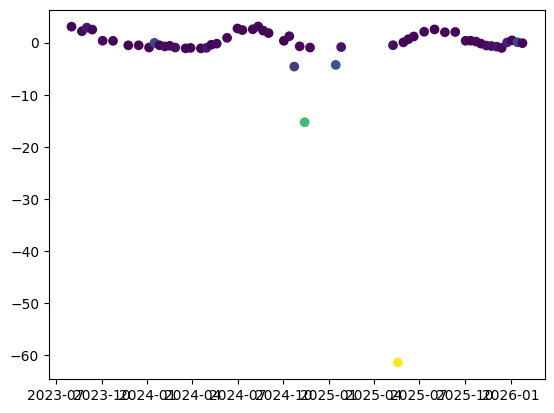

In [85]:
reach_df  = swot.loc['81110200041'].copy()

import matplotlib.pyplot as plt
plt.scatter(reach_df.index, reach_df['d_wse'], c=reach_df['wse_u'])

In [86]:
reach_df['wse_u'].max()

0.1982

In [158]:
def get_best_record(grp):
    return grp.sort_values('wse_u').iloc[0]


def safe_xs(df, val, level):
    try:
        return df.xs(val, level=level)
    except KeyError:
        return pd.DataFrame()
        
def get_swot_r(reach_id, swot):
    swot_reach = pd.concat([safe_xs(swot, rid, 'reach_id') for rid in reach_ids])
        
    swot_reach.index = pd.to_datetime(swot_reach.index).round('D').tz_localize('UTC')
    swot_reach.index.name = 'date'
    
    # For any duplicated dates, pick the best obs according to uncertainty estimate.
    if any(swot_reach.index.duplicated()):
        swot_reach = swot_reach.groupby(swot_reach.index.name).apply(get_best_record)

    return swot_reach.add_suffix('_river')


BATCH_SIZE = 10000
batches = []
for basin_id, basin_group in merged.groupby('outlet_id'):
    basin_subs = basin_subbasin_dict[basin_id]
    n_subs = len(basin_subs)

    for i in range(0, n_subs, BATCH_SIZE):
        batch_subs = basin_subs[i : i + BATCH_SIZE]
        batches.append((basin_id, batch_subs))


for basin_id, batch_subs in tqdm(batches):
    basin_subs = basin_subbasin_dict[basin_id]
    batch_df_list = []
    for subbasin in batch_subs:
        try:
            reach_ids = merged.loc[subbasin]['reach_id']
        except:
            continue

        if isinstance(reach_ids, pd.Series):
            reach_ids = reach_ids.values.astype(int).astype(str)
        elif isinstance(reach_ids, np.float64):
            reach_ids = [str(int(reach_ids))]
            
        swot_df = get_swot_r(reach_ids, swot)

        if swot_df is not None and not swot_df.empty:
            swot_df['subbasin'] = subbasin
            swot_df.index.name = 'date'
            batch_df_list.append(swot_df)

    # If the whole batch is empty, we technically don't need to write anything 
    # since the zarr was initialized with NaNs/empty).
    if batch_df_list:
        batch_df = pd.concat(batch_df_list)
        store.write_batch_data(basin_id, batch_df, basin_subs, batch_subs)

100%|██████████| 367/367 [45:57<00:00,  7.51s/it]  


In [155]:
any(swot_df.index.duplicated())

False

In [135]:
swot.xs('111', level='reach_id')

KeyError: '111'

In [70]:
merged.set_index('site_id')

,is_gauge,uparea_km2,outlet_id,original_comid,COMID_v07,COMID,reach_id
site_id,,,,,,,
23020936,False,625.114709,EAUF-A3750050,23020936,23020606,23020606.0,2.326900e+10
23020936,False,625.114709,EAUF-A3750050,23020936,23020606,23020606.0,2.326900e+10
23020927,False,948.431597,EAUF-A3750050,23020927,23020605,23020605.0,2.326900e+10
23020916,False,952.117079,EAUF-A3750050,23020916,23020713,23020713.0,2.326800e+10
23020913,False,775.731383,EAUF-A3750050,23020913,23020712,23020712.0,2.326900e+10
...,...,...,...,...,...,...,...
81001413,False,2751.705206,USGS-15908000,81001413,81002593,81002593.0,8.139040e+10
81001413,False,2751.705206,USGS-15908000,81001413,81002593,81002593.0,8.139040e+10
81001413,False,2751.705206,USGS-15908000,81001413,81002593,81002593.0,8.139040e+10
